# A1 — Анализ строковых сортировок

### ID посылок

- A1m  — [375920336](https://dsahse25.contest.codeforces.com/group/SLdI1pWUpC/contest/691754/submission/375920336)
- A1q  — [375920948](https://dsahse25.contest.codeforces.com/group/SLdI1pWUpC/contest/691754/submission/375920948)
- A1r  — [375924006](https://dsahse25.contest.codeforces.com/group/SLdI1pWUpC/contest/691754/submission/375924006)
- A1rq — [375925958](https://dsahse25.contest.codeforces.com/group/SLdI1pWUpC/contest/691754/submission/375925958)

Ссылка на гит репозиторий: [Github](https://github.com/Egorixa/algs_Set9_2026)

Использовались следующие константы: длины строк от 10 до 200 символов; размеры массивов от 100 до 3000 с шагом 100; каждое измерение было усреднено по 3 запускам.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

datasets = ['random', 'reverse', 'almost', 'prefix']
ds_label = {
    'random':  'случайные',
    'reverse': 'обратно отсортированные',
    'almost':  'почти отсортированные',
    'prefix':  'с общими префиксами',
}

frames = []
for ds in datasets:
    fn = f'{ds}-results.txt'
    if os.path.exists(fn):
        d = pd.read_csv(fn, header=None, names=['n', 'algo', 'time_us', 'char_cmp'],
                        skipinitialspace=True)
        d['dataset'] = ds
        frames.append(d)
df = pd.concat(frames, ignore_index=True)
df.head()

,n,algo,time_us,char_cmp,dataset
0,100,std_quick,3.069,817,random
1,100,std_merge,4.778,605,random
2,100,string_merge,5.611,522,random
3,100,string_quick,2.709,750,random
4,100,msd_radix,8.083,176,random


In [38]:
algos = ['std_quick', 'std_merge', 'string_merge', 'string_quick', 'msd_radix', 'msd_radix_qs']
algo_label = {
    'std_quick':    'std QuickSort',
    'std_merge':    'std MergeSort',
    'string_merge': 'String MergeSort (LCP)',
    'string_quick': 'String QuickSort (3-way)',
    'msd_radix':    'MSD Radix',
    'msd_radix_qs': 'MSD Radix + QuickSort',
}
colors = plt.cm.tab10(np.linspace(0, 1, len(algos)))
algo_color = dict(zip(algos, colors))

### Время работы

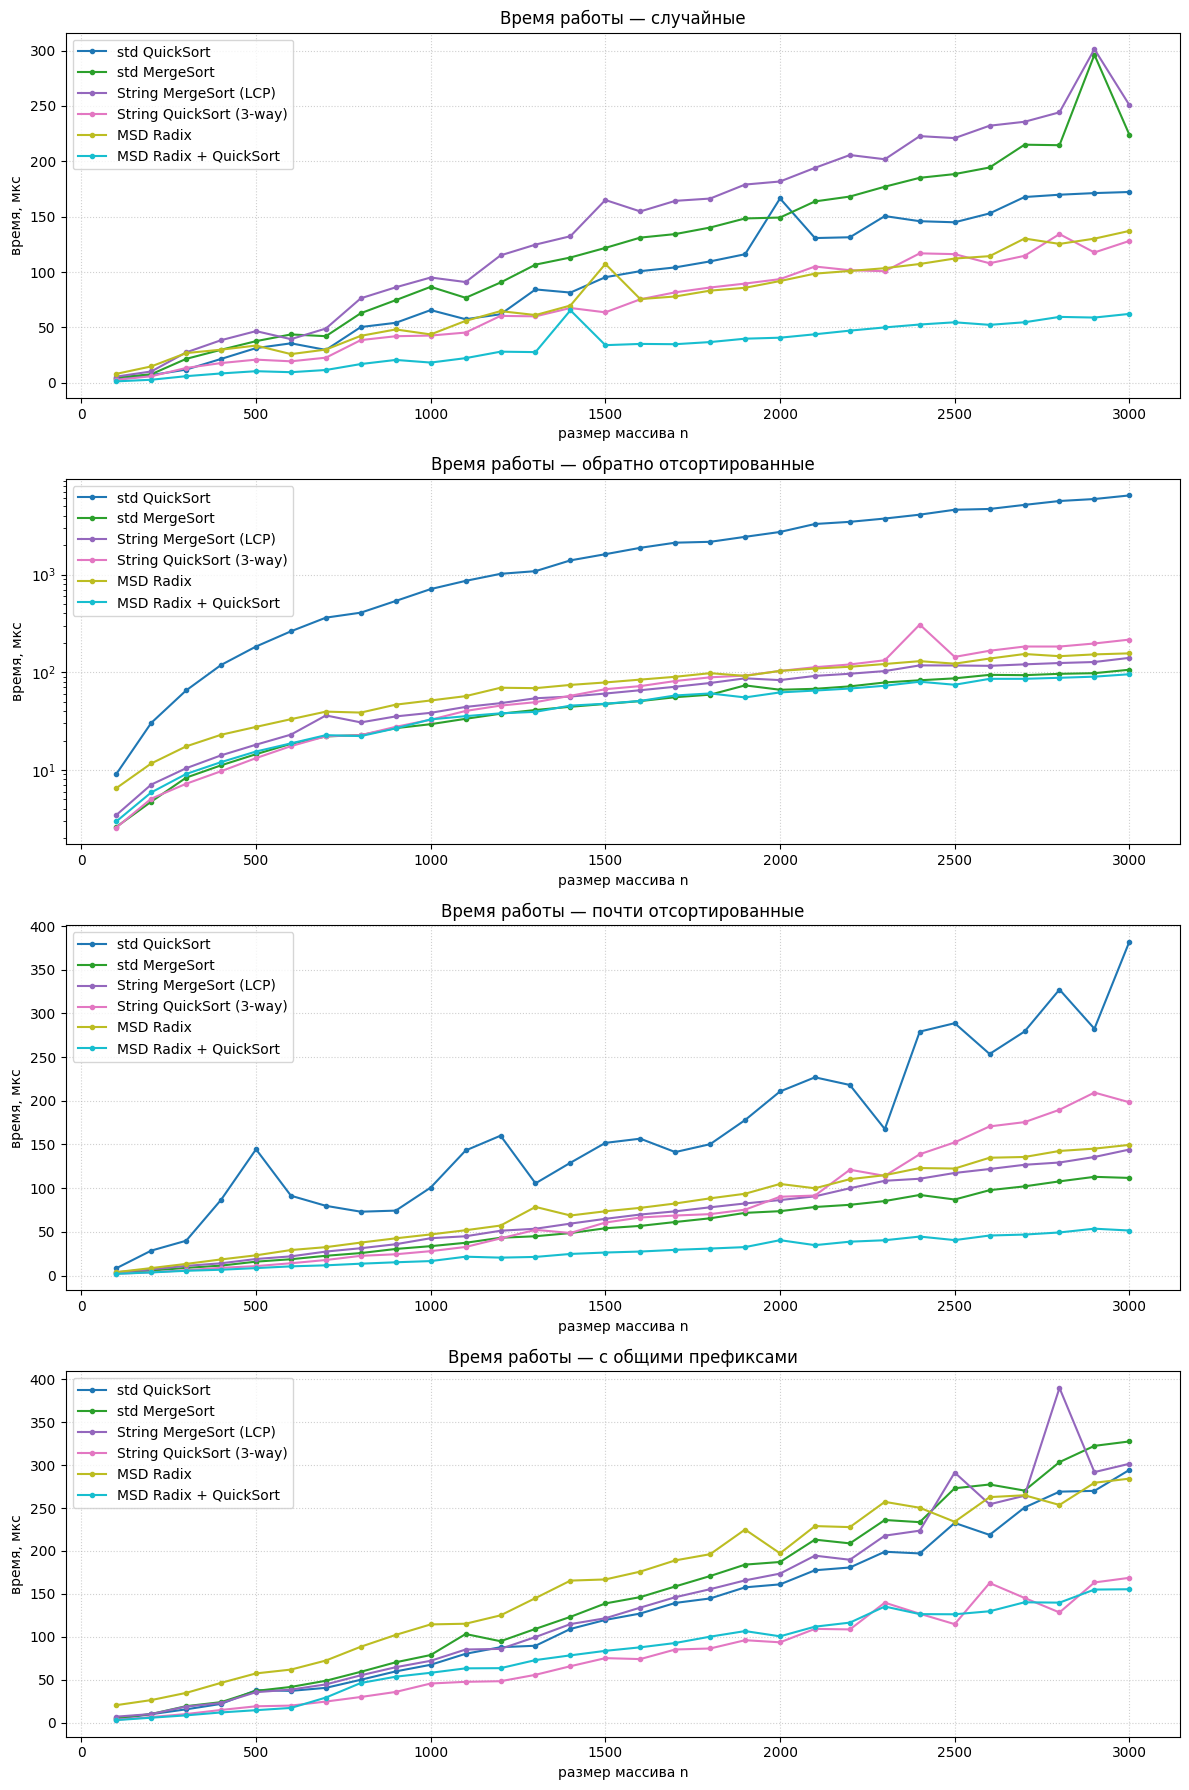

In [39]:
fig, axes = plt.subplots(nrows=len(datasets), ncols=1, figsize=(12, 4.5 * len(datasets)))
for i, ds in enumerate(datasets):
    ax = axes[i]
    sub = df[df['dataset'] == ds]
    for a in algos:
        d = sub[sub['algo'] == a].sort_values('n')
        ax.plot(d['n'], d['time_us'], marker='o', markersize=3, linewidth=1.5,
                color=algo_color[a], label=algo_label[a])
    ax.set_title(f'Время работы — {ds_label[ds]}')
    ax.set_xlabel('размер массива n')
    ax.set_ylabel('время, мкс')
    ax.grid(True, linestyle=':', alpha=0.6)
    if ds == 'reverse':
        ax.set_yscale('log')
    ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

Как мы видим, по времени везде впереди гибрид `msd_radix_qs`.

На reverse `std_quick` уходит в O($n^2$) — около 6.4 мс против 100–250 мкс у всех остальных. Это ожидаемое следствие выбора первого опорного; `string_quick` с тем же правилом устойчив, потому что разбивается по байту, а не по полной строке.

### Число посимвольных сравнений

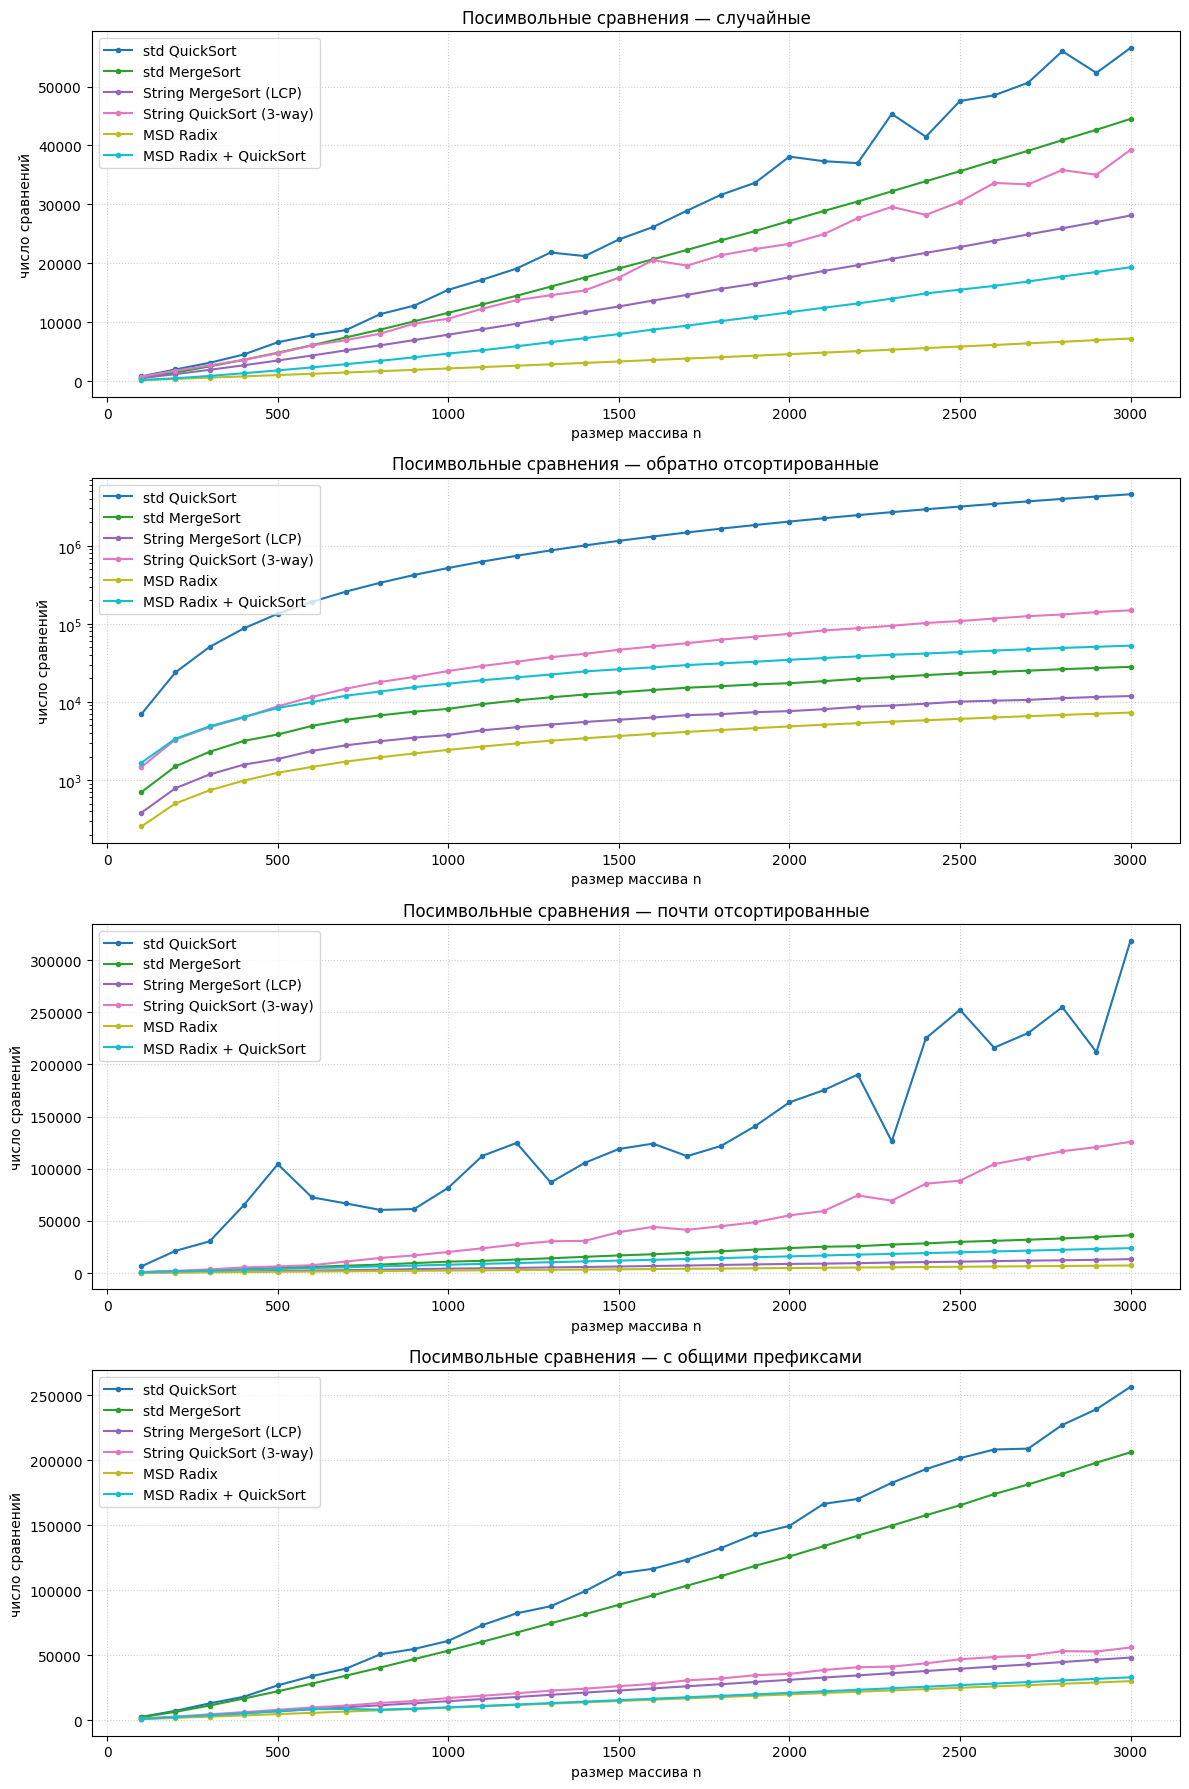

In [40]:
fig, axes = plt.subplots(nrows=len(datasets), ncols=1, figsize=(12, 4.5 * len(datasets)))
for i, ds in enumerate(datasets):
    ax = axes[i]
    sub = df[df['dataset'] == ds]
    for a in algos:
        d = sub[sub['algo'] == a].sort_values('n')
        ax.plot(d['n'], d['char_cmp'], marker='o', markersize=3, linewidth=1.5,
                color=algo_color[a], label=algo_label[a])
    ax.set_title(f'Посимвольные сравнения — {ds_label[ds]}')
    ax.set_xlabel('размер массива n')
    ax.set_ylabel('число сравнений')
    ax.grid(True, linestyle=':', alpha=0.6)
    if ds == 'reverse':
        ax.set_yscale('log')
    ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

По сравнениям абсолютный минимум держит `msd_radix` — ~7.3 тыс. на $n=3000$ независимо от типа массива, потому что радикс читает каждый символ ровно столько раз, сколько нужно для различения строк.

Главный эффект LCP-сравнения виден на prefix: `string_merge` тратит ~48 тыс. сравнений против ~206 тыс. у `std_merge` — в 4 раза меньше. На случайных массивах разница скромнее (28 тыс. против 44 тыс.), потому что общих префиксов мало и переиспользовать почти нечего.

### Стандартный vs адаптированный

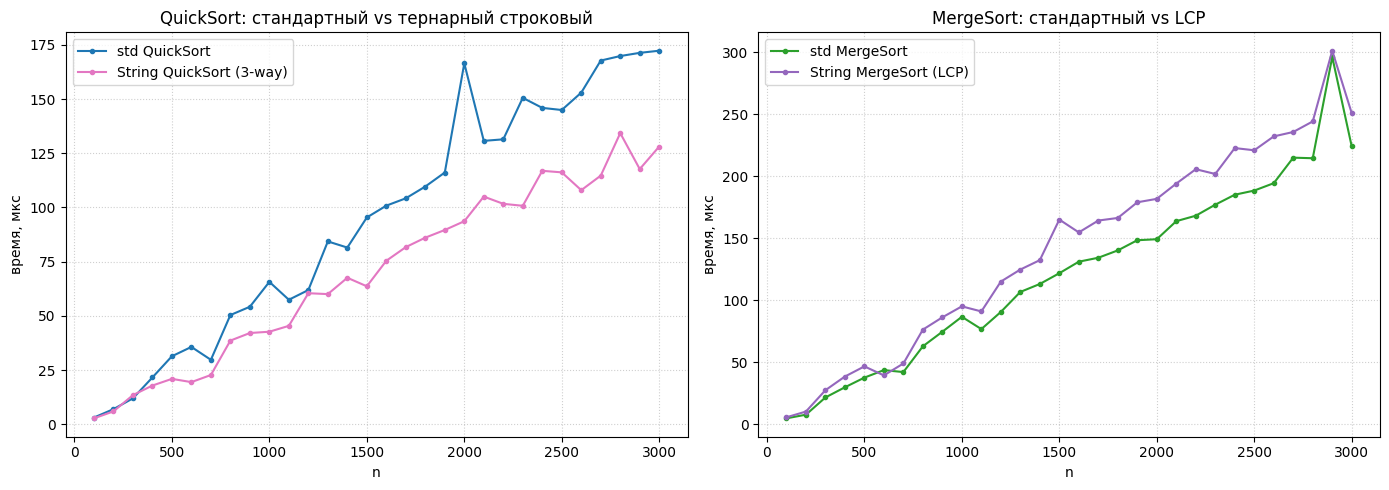

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rnd = df[df['dataset'] == 'random']
pairs = [('std_quick', 'string_quick', 'QuickSort: стандартный vs тернарный строковый'),
         ('std_merge', 'string_merge', 'MergeSort: стандартный vs LCP')]
for ax, (a, b, title) in zip(axes, pairs):
    for algo in (a, b):
        d = rnd[rnd['algo'] == algo].sort_values('n')
        ax.plot(d['n'], d['time_us'], marker='o', markersize=3, linewidth=1.5,
                color=algo_color[algo], label=algo_label[algo])
    ax.set_title(title)
    ax.set_xlabel('n'); ax.set_ylabel('время, мкс')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()
plt.tight_layout()
plt.show()

В паре QuickSort адаптация выигрывает: `string_quick` ~140 мкс против 185 мкс у `std_quick` на random при $n=3000$, и на порядки лучше на reverse.

В паре MergeSort на случайных данных адаптация почти одинаковая (выигрыш по сравнениям съедается поддержкой массива длин), но на массивах с общими префиксами `string_merge` уверенно обходит `std_merge` и по сравнениям, и по времени.

### Теоретические оценки

| Алгоритм | Оценка |
|---|---|
| std QuickSort  | $O(n \log n \cdot L)$ в среднем, $L$ — средняя длина строки; $O(n^2 \cdot L)$ на отсортированном/обратно отсортированном входе при выборе первого опорным |
| std MergeSort  | $O(n \log n \cdot L)$ |
| String MergeSort (LCP) | $O(n \log n + \Sigma\,\mathrm{LCP}(R))$ |
| String QuickSort (3-way) | $O(n \log n + \Sigma\,\mathrm{LCP}(R))$ в среднем |
| MSD Radix | $O(N)$, где $N$ — суммарная длина; накладные расходы на корзины при малых подмассивах |
| MSD Radix + QuickSort | $O(N)$ с меньшей константой за счёт переключения |

Опорный элемент в `std_quick` и `string_quick` выбирается одинаково — первый в подмассиве.

На случайных массивах радикс-сортировки быстрее сравнительных при больших $n$.

На почти отсортированных классический MergeSort эффективен (мало реальных слияний), а LCP-MergeSort ещё лучше: общие префиксы соседних строк длинные и переиспользуются.

На массивах с общими префиксами хорошо виден выигрыш LCP-merge и string-quicksort по числу сравнений по сравнению со стандартными версиями.

### Сводная таблица (n = 3000)

In [42]:
big = df[df['n'] == 3000].pivot_table(index='algo', columns='dataset', values=['time_us', 'char_cmp'])
big = big.reindex(algos)
big

char_cmp                                time_us           \
dataset         almost    prefix   random    reverse   almost   prefix   
algo                                                                     
std_quick     318754.0  256471.0  56553.0  4559727.0  382.139  294.430   
std_merge      36127.0  206120.0  44511.0    28100.0  111.736  327.653   
string_merge   13291.0   48268.0  28124.0    11880.0  144.208  301.611   
string_quick  125800.0   56013.0  39262.0   148903.0  198.334  168.695   
msd_radix       7232.0   30111.0   7246.0     7298.0  149.569  284.278   
msd_radix_qs   23866.0   33076.0  19336.0    52586.0   51.528  155.389   

                                 
dataset        random   reverse  
algo                             
std_quick     172.292  6445.875  
std_merge     224.055   106.056  
string_merge  250.833   140.278  
string_quick  128.097   215.694  
msd_radix     137.153   156.014  
msd_radix_qs   62.222    95.389

Как мы видим, для практического применения оптимален `msd_radix_qs` — он лучший по времени на всех четырёх типах данных и почти лучший по сравнениям. Чистый `msd_radix` даёт минимум сравнений, но проигрывает по времени из-за накладных расходов на 257 корзин при малых подмассивах.

Из сравнительных алгоритмов `string_merge` лучший выбор, если в данных есть общие префиксы; иначе `string_quick` обычно быстрее. `std_quick` с первым опорным использовать нельзя — на отсортированных входах он работает долго ($O(n^2)$)